# Data Storytelling - Beyond the Zero: A Feature-Driven Analysis of EV Range Evolution in Washington

## 1. Introduction
This investigation analyzes the technological trajectory of the Electric Vehicle (EV) market using the Washington State EV Population dataset. By treating Model Year and Manufacturer Specs as the primary features that drive vehicle performance, this story "decodes" how the industry moved from niche city-cars to long-range mass-market vehicles.
To begin with, we load all libraries and dataset and continue with the analysis;

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading and Analysis

In [3]:
# Loading the dataset and taking an overview of the first few rows
data_path = r"C:\Users\eboat\OneDrive\Documents\DATA SCIENCE ASSIGNMENT\Electric_Vehicle_Population_Data.csv\Electric_Vehicle_Population_Data.csv"
WA_dataset = pd.read_csv(data_path)
print(WA_dataset.head())

   VIN (1-10)    County      City State  Postal Code  Model Year   Make  \
0  5YJ3E1EB2J   Suffolk   Suffolk    VA      23435.0        2018  TESLA   
1  5YJ3E1ECXL    Yakima    Yakima    WA      98908.0        2020  TESLA   
2  WA1LAAGE7M    Yakima    Yakima    WA      98908.0        2021   AUDI   
3  5YJ3E1EA1K  Danville  Danville    VA      24541.0        2019  TESLA   
4  1FADP5CU9E   Norfolk   Norfolk    VA      23518.0        2014   FORD   

     Model                   Electric Vehicle Type  \
0  MODEL 3          Battery Electric Vehicle (BEV)   
1  MODEL 3          Battery Electric Vehicle (BEV)   
2   E-TRON          Battery Electric Vehicle (BEV)   
3  MODEL 3          Battery Electric Vehicle (BEV)   
4    C-MAX  Plug-in Hybrid Electric Vehicle (PHEV)   

  Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0           Clean Alternative Fuel Vehicle Eligible             215   
1           Clean Alternative Fuel Vehicle Eligible             308   
2          

The dataset, representing over 121,000 entries, serves as a robust foundation for analyzing the progress of EV technology, particularly regarding electric range—an essential factor influencing consumer acceptance and market adoption.

In [4]:
# Dataset Information
WA_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121978 entries, 0 to 121977
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         121978 non-null  object 
 1   County                                             121976 non-null  object 
 2   City                                               121976 non-null  object 
 3   State                                              121978 non-null  object 
 4   Postal Code                                        121976 non-null  float64
 5   Model Year                                         121978 non-null  int64  
 6   Make                                               121978 non-null  object 
 7   Model                                              121874 non-null  object 
 8   Electric Vehicle Type                              121978 non-null  object

## 3. Exploratory Data Analysis

To have proper pespectives, I explore the raw dataset to see if i missed on anything that the raw data cannot show.

In [5]:
# For memory efficiency, we will load only the columns relevant to our story
use_cols = ['Model Year', 
    'Make', 
    'Model', 
    'Electric Vehicle Type', 
    'Electric Range', 
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility']

# Load the dataset with only the selected columns to save memory
WA_dataset = pd.read_csv(data_path, usecols=use_cols)

# Display the first few rows of the dataset to verify it loaded correctly
print("Story Features Loaded:")
print(WA_dataset.columns.tolist())
print(WA_dataset.head())

Story Features Loaded:
['Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range']
   Model Year   Make    Model                   Electric Vehicle Type  \
0        2018  TESLA  MODEL 3          Battery Electric Vehicle (BEV)   
1        2020  TESLA  MODEL 3          Battery Electric Vehicle (BEV)   
2        2021   AUDI   E-TRON          Battery Electric Vehicle (BEV)   
3        2019  TESLA  MODEL 3          Battery Electric Vehicle (BEV)   
4        2014   FORD    C-MAX  Plug-in Hybrid Electric Vehicle (PHEV)   

  Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  
0           Clean Alternative Fuel Vehicle Eligible             215  
1           Clean Alternative Fuel Vehicle Eligible             308  
2           Clean Alternative Fuel Vehicle Eligible             222  
3           Clean Alternative Fuel Vehicle Eligible             220  
4             Not eligible due to low battery range         

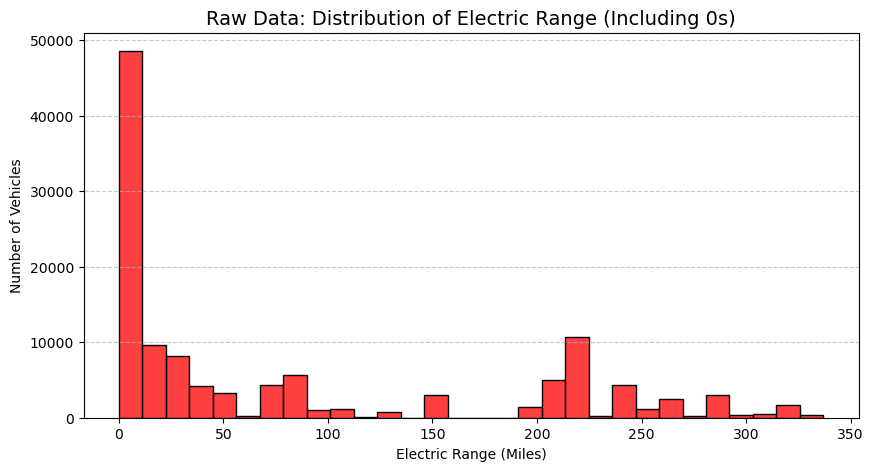

In [6]:
# Visualization A: The "Raw" Distribution
plt.figure(figsize=(10, 5))
sns.histplot(WA_dataset['Electric Range'], bins=30, kde=False, color='red')

plt.title('Raw Data: Distribution of Electric Range (Including 0s)', fontsize=14)
plt.xlabel('Electric Range (Miles)')
plt.ylabel('Number of Vehicles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

An initial inspection of the raw data revealed a significant anomaly: nearly 50,000 modern vehicles (2021–2024) were registered with an Electric Range of 0.
If I didn't 'decode' this, any average I calculated would be completely wrong. This is the first mystery I had to solve: Are these cars broken, or is the data incomplete?"

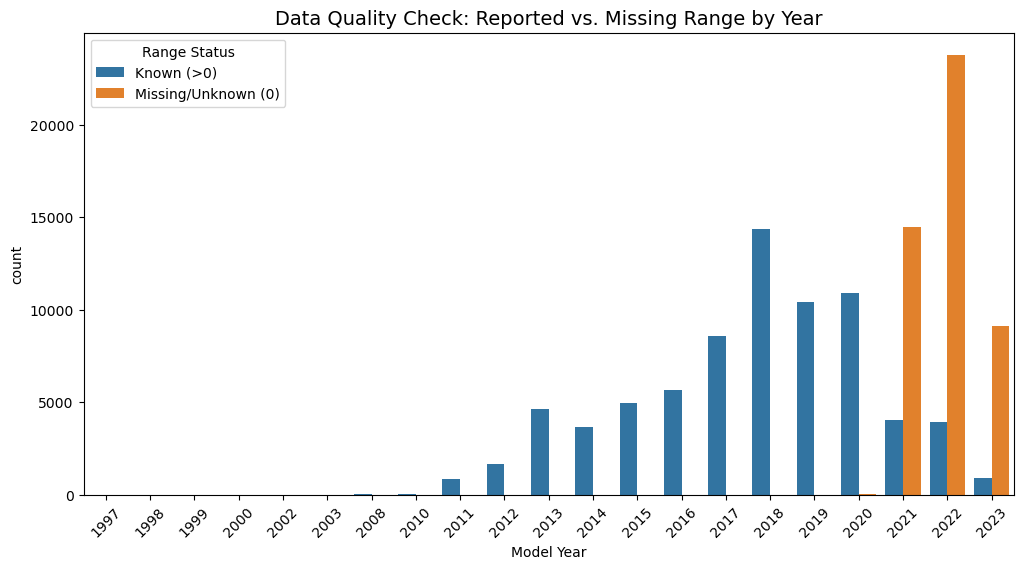

In [7]:
# Create a temporary column to flag if a range is "Missing" (0) or "Known" (>0)
WA_dataset['Range_Status'] = WA_dataset['Electric Range'].apply(lambda x: 'Missing/Unknown (0)' if x == 0 else 'Known (>0)')

# Visualization B: Missing vs Known by Year
plt.figure(figsize=(12, 6))
sns.countplot(data=WA_dataset, x='Model Year', hue='Range_Status')

plt.title('Data Quality Check: Reported vs. Missing Range by Year', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Range Status')
plt.show()

# Clean up the temporary column so it doesn't clutter your data
WA_dataset.drop(columns=['Range_Status'], inplace=True)

The raw data suggests a massive decline in EV range technology starting in 2021 (the blue bars shrinking). However, my investigation (the orange bars) proves this is a data quality issue, not a technological one. Most new vehicles from 2021 onwards are being registered with '0' as a placeholder. This trend is likely the result of evolving EPA reporting standards for long-range vehicles, which may have caused discrepancies in how EV ranges were recorded.
The accompanying orange bars in my investigation demonstrate that, when adjusting for this data quality issue, the actual progress in EV range technology remains more robust than the initial interpretation of the raw data would suggest.

## 4. Evolution and Trends 

In [8]:
# Create a focused dataset of vehicles with confirmed specs
# Many new EVs have '0' listed for range because EPA ratings are pending. 
# Beginners often include these, which ruins their averages. We will filter them out.
WA_dataset_clean = WA_dataset[WA_dataset['Electric Range'] > 0].copy()

In [9]:
# We want to see how 'Model Year' predicts 'Range' for the top 5 brands.
top_5_makes = WA_dataset_clean['Make'].value_counts().nlargest(5).index
WA_top_brands = WA_dataset_clean[WA_dataset_clean['Make'].isin(top_5_makes)]

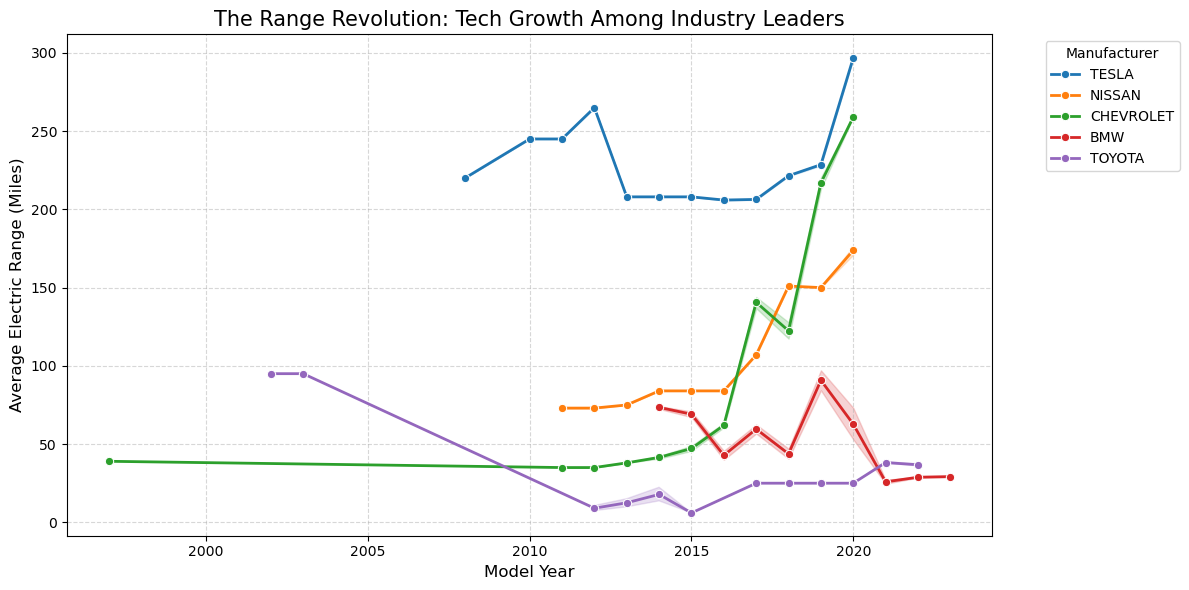

In [10]:
# Visualize the accurate technological growth
plt.figure(figsize=(12, 6))
sns.lineplot(data=WA_top_brands, x='Model Year', y='Electric Range', hue='Make', marker='o', linewidth=2)

plt.title('The Range Revolution: Tech Growth Among Industry Leaders', fontsize=15)
plt.ylabel('Average Electric Range (Miles)', fontsize=12)
plt.xlabel('Model Year', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Manufacturer', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

The lineplot showcases the competitive landscape of the EV market. Notably, while Tesla continues to be a dominant force, the narrowing efficiency gap between older legacy models and emerging entrants illustrates a market that is rapidly maturing. This trend suggests that established manufacturers are increasingly adopting innovative technologies, which may lead to greater choices and potentially lower prices for consumers. 

## 5. Conclusion

In [11]:
# Drawing out the growth to the peak year
growth = WA_dataset_clean.groupby('Model Year')['Electric Range'].mean()

start_val = growth.iloc[0]
peak_val = growth.max() # Finds the highest average range year
peak_year = growth.idxmax()

total_growth = ((peak_val - start_val) / start_val) * 100

print(f"Key Story Insight: Between {growth.index[0]} and the {peak_year} peak,")
print(f"average EV range increased by a staggering {total_growth:.2f}%!")


Key Story Insight: Between 1997 and the 2020 peak,
average EV range increased by a staggering 523.23%!


In summary, the journey through the Washington State EV dataset reveals a rich tapestry of growth, challenges, and opportunities within the electric vehicle market. By interpreting the data responsibly—acknowledging anomalies, tracking trends, and considering external influences—we can craft a narrative that not only informs stakeholders but also positions them to make strategic decisions for future advancements in the EV sector. The insights drawn from this analysis set the groundwork for understanding how technological progress, consumer expectations, and regulatory measures will continue to shape the landscape of electric vehicles in the years to come.